# Instituto Tecnológico y de Estudios Superiores de Monterrey
## Escuela de Ingenierías  
## Maestría en Inteligencia Artificial Aplicada  
## Proyecto Integrador (TC5035 - Grupo 10)

---

# Avance 4 – Modelos Alternativos
## Proyecto Integrador TC5035 – Grupo 28

**Integrantes del grupo:**

- Carolina Gómez Fernández – A01305369  
- Jorge Eduardo Reyes de la Rosa – A00282698  
- Enrique Jiménez Téllez – A01796026  


# Objetivos

- Explorar una gama diversa de técnicas y enfoques con el fin de identificar el de mejor desempeño en el conjunto de datos en cuestión.

- Encontrar la configuración óptima que maximiza el rendimiento del modelo en una tarea específica.

## 0. Configuración inicial e importación de librerías

En esta sección se importan las librerías necesarias para el manejo de datos, entrenamiento de modelos, evaluación de métricas y visualización de resultados.  
También se define la variable objetivo, la semilla aleatoria y parámetros generales para asegurar reproducibilidad.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

RANDOM_STATE = 42
TARGET = "Target_Reprobado"

pd.set_option("display.max_columns", None)

## 1. Carga de datos

Aquí se monta Google Drive y se cargan los archivos generados en el Avance 2.  
Estos archivos contienen los conjuntos de entrenamiento y prueba ya procesados mediante ingeniería de características. Los conjuntos de entrenamiento y prueba fueron generados en el Avance 2 y se reutilizan en este avance para garantizar comparabilidad entre los modelos evaluados

In [ ]:
drive.mount("/content/drive")


ruta_base = "/content/drive/MyDrive/Proyecto Integrador/Versiones Finales/Avance 4"

train_path = os.path.join(ruta_base, "dataset_train_feature_engineering.csv")
test_path = os.path.join(ruta_base, "dataset_test_feature_engineering.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Dimensiones del conjunto de entrenamiento:", train_df.shape)
print("Dimensiones del conjunto de prueba:", test_df.shape)

display(train_df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dimensiones del conjunto de entrenamiento: (1192, 17)
Dimensiones del conjunto de prueba: (298, 17)


,Año_lectivo,Promedio de ingreso,Evaluación_1,Evaluación_2,Evaluación_3,Tareas_y_Pruebas_Cortas,Promedio_Evaluaciones,Desviacion_Evaluaciones,Diferencia_Eval3_Eval1,Ratio_Tareas_vs_Evaluaciones,Nivel_Distancia_Muy_cerca,Nivel_Promedio_Ingreso_Alto,Nivel_Promedio_Ingreso_Bajo,Nivel_Promedio_Ingreso_Muy_alto,Nivel_Promedio_Ingreso_Muy_bajo,Profesor,Target_Reprobado
0,-1.547406,1.815152,-0.271123,-1.300449,0.625233,1.985579,-0.240928,1.193730,0.913813,0.587437,1.0,1.0,0.0,0.0,0.0,-1.898955,1
1,0.222189,-1.140500,0.365479,0.015388,1.019268,-0.507075,0.641470,0.567877,0.876248,-0.443776,0.0,0.0,0.0,0.0,1.0,0.630560,1
2,-0.367676,0.930930,0.458188,-1.095763,0.812711,0.822483,0.172526,1.284042,0.571968,-0.015749,0.0,1.0,0.0,0.0,0.0,-0.453518,1
3,1.401919,-1.447608,-0.716126,0.161592,-0.959205,-0.357686,-0.666482,0.015830,-0.541848,-0.049357,0.0,0.0,0.0,0.0,1.0,0.269200,1
4,1.401919,2.192338,1.539792,1.565151,1.205917,0.472487,1.684493,-0.582136,0.195374,-0.372890,0.0,0.0,0.0,1.0,0.0,-1.176236,0


## 2. Separación de variables predictoras y variable objetivo

En esta sección se separa `Target_Reprobado` del resto de variables.  
Las variables predictoras se almacenan en `X_train` y `X_test`, mientras que la variable objetivo se almacena en `y_train` y `y_test`.

In [ ]:
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1192, 16)
X_test: (298, 16)
y_train: (1192,)
y_test: (298,)


## 3. Distribución de la variable objetivo

Se revisa la proporción de estudiantes aprobados y reprobados en los conjuntos de entrenamiento y prueba.  
Este análisis permite identificar si existe desbalance de clases y justificar la selección de métricas como F1-Score y Recall.


Distribución de clases en entrenamiento:


,conteo,porcentaje
Target_Reprobado,,
1,658,55.201342
0,534,44.798658



Distribución de clases en prueba:


,conteo,porcentaje
Target_Reprobado,,
1,164,55.033557
0,134,44.966443


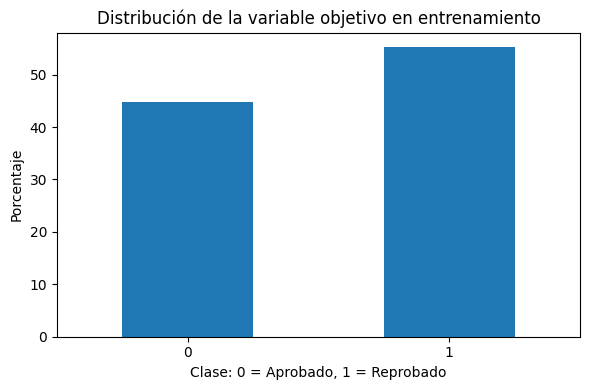

In [ ]:
dist_train = y_train.value_counts().to_frame("conteo")
dist_train["porcentaje"] = y_train.value_counts(normalize=True) * 100

dist_test = y_test.value_counts().to_frame("conteo")
dist_test["porcentaje"] = y_test.value_counts(normalize=True) * 100

print("\nDistribución de clases en entrenamiento:")
display(dist_train)

print("\nDistribución de clases en prueba:")
display(dist_test)

plt.figure(figsize=(6, 4))
(y_train.value_counts(normalize=True) * 100).sort_index().plot(kind="bar")
plt.title("Distribución de la variable objetivo en entrenamiento")
plt.xlabel("Clase: 0 = Aprobado, 1 = Reprobado")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Justificación de métricas

MÉTRICA PRINCIPAL SELECCIONADA: F1-Score

El problema corresponde a clasificación binaria, donde la clase positiva es Target_Reprobado = 1.
El objetivo principal es identificar estudiantes con riesgo de reprobar.

Se utiliza F1-Score como métrica principal porque combina Precision y Recall.
Esto es importante porque no solo interesa acertar en general, sino detectar correctamente
a los estudiantes en riesgo, evitando al mismo tiempo un exceso de falsos positivos.

También se reportan Accuracy, Balanced Accuracy, Precision, Recall y ROC-AUC
para obtener una evaluación más completa.

Aunque la distribución de clases es relativamente balanceada (55% reprobados y 45% aprobados), se mantiene F1-Score como métrica principal debido a que el costo académico de no identificar oportunamente a un estudiante en riesgo de reprobación es mayor que el de generar una alerta preventiva adicional

## 4. Función general de evaluación

Implementamos una función general que permite entrenar y evaluar todos los modelos bajo las mismas condiciones experimentales. Para cada modelo se calculan métricas de clasificación (Accuracy, Balanced Accuracy, Precision, Recall, F1-Score y ROC-AUC), tiempos de entrenamiento y diferencias de desempeño entre entrenamiento y prueba, esto facilita la comparación objetiva de los algoritmos evaluados.

In [ ]:
def evaluar_modelo(nombre, modelo, X_train, y_train, X_test, y_test):

    inicio = time.time()
    modelo.fit(X_train, y_train)
    fin = time.time()

    tiempo_entrenamiento = fin - inicio

    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    if hasattr(modelo, "predict_proba"):
        y_score_train = modelo.predict_proba(X_train)[:, 1]
        y_score_test = modelo.predict_proba(X_test)[:, 1]
        roc_train = roc_auc_score(y_train, y_score_train)
        roc_test = roc_auc_score(y_test, y_score_test)
    else:
        roc_train = np.nan
        roc_test = np.nan

    resultado = {
        "Modelo": nombre,

        "Accuracy Train": accuracy_score(y_train, y_pred_train),
        "Accuracy Test": accuracy_score(y_test, y_pred_test),

        "Balanced Accuracy Train": balanced_accuracy_score(y_train, y_pred_train),
        "Balanced Accuracy Test": balanced_accuracy_score(y_test, y_pred_test),

        "Precision Train": precision_score(y_train, y_pred_train, zero_division=0),
        "Precision Test": precision_score(y_test, y_pred_test, zero_division=0),

        "Recall Train": recall_score(y_train, y_pred_train, zero_division=0),
        "Recall Test": recall_score(y_test, y_pred_test, zero_division=0),

        "F1 Train": f1_score(y_train, y_pred_train, zero_division=0),
        "F1 Test": f1_score(y_test, y_pred_test, zero_division=0),

        "ROC-AUC Train": roc_train,
        "ROC-AUC Test": roc_test,

        "Diferencia F1 Train-Test": (
            f1_score(y_train, y_pred_train, zero_division=0) -
            f1_score(y_test, y_pred_test, zero_division=0)
        ),

        "Tiempo entrenamiento (seg)": tiempo_entrenamiento
    }

    print("\n====================================================")
    print(nombre)
    print("====================================================")
    print(classification_report(y_test, y_pred_test, zero_division=0))

    matriz = confusion_matrix(y_test, y_pred_test)
    fig, ax = plt.subplots(figsize=(6,5))
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax,
        colorbar=False
    )
    plt.title("Matriz de confusión - " + nombre)
    plt.tight_layout()
    plt.show()

    if hasattr(modelo, "predict_proba"):
        RocCurveDisplay.from_estimator(modelo, X_test, y_test)
        plt.title("Curva ROC - " + nombre)
        plt.tight_layout()
        plt.show()

    return resultado, modelo

## 5. Modelos alternativos

Con base en los resultados obtenidos en el Avance 3, se decidió profundizar en los algoritmos que mostraron el mejor desempeño (Árbol de Decisión y Random Forest) e incorporar un modelo adicional basado en distancia (KNN) para contrastar enfoques metodológicos diferentes.

La selección de estos modelos busca comparar:

Modelos interpretables basados en reglas (Árbol de Decisión).
Modelos de ensamble con capacidad de generalización (Random Forest).
Modelos basados en similitud entre observaciones (KNN).

Esta estrategia permite evaluar diferentes mecanismos de aprendizaje sin incrementar innecesariamente la complejidad experimental, enfocando el análisis en los modelos más prometedores identificados durante las etapas previas del proyecto.

In [ ]:
modelos = {
    "Árbol de Decisión": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "KNN": KNeighborsClassifier()
}

## 6. Entrenamiento y comparación inicial


Árbol de Decisión
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       134
           1       0.95      0.92      0.93       164

    accuracy                           0.93       298
   macro avg       0.93      0.93      0.93       298
weighted avg       0.93      0.93      0.93       298



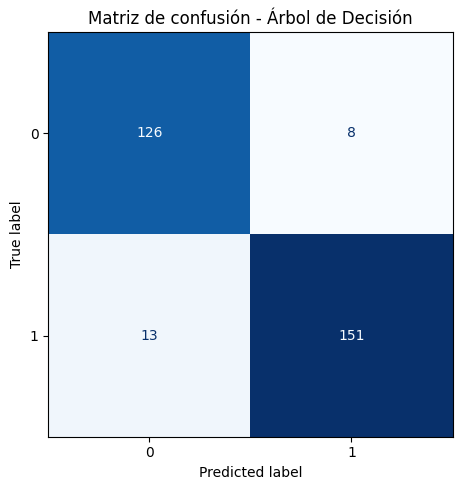

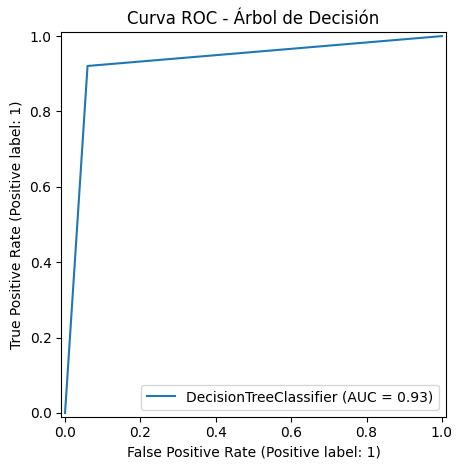


Random Forest
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       134
           1       0.96      0.93      0.94       164

    accuracy                           0.94       298
   macro avg       0.94      0.94      0.94       298
weighted avg       0.94      0.94      0.94       298



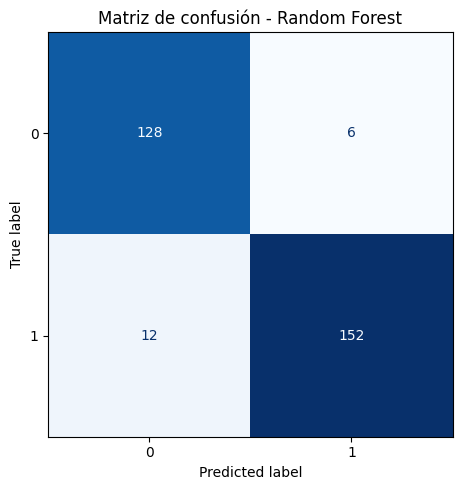

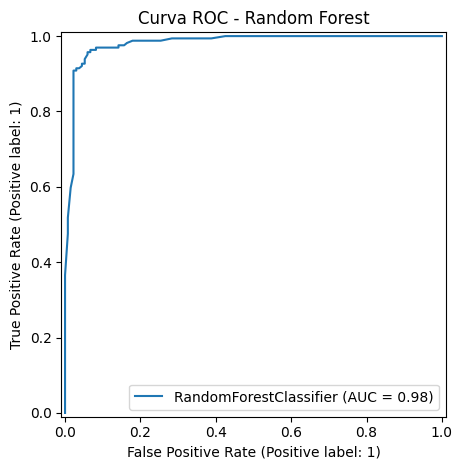


KNN
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       134
           1       0.95      0.88      0.91       164

    accuracy                           0.91       298
   macro avg       0.91      0.91      0.91       298
weighted avg       0.91      0.91      0.91       298



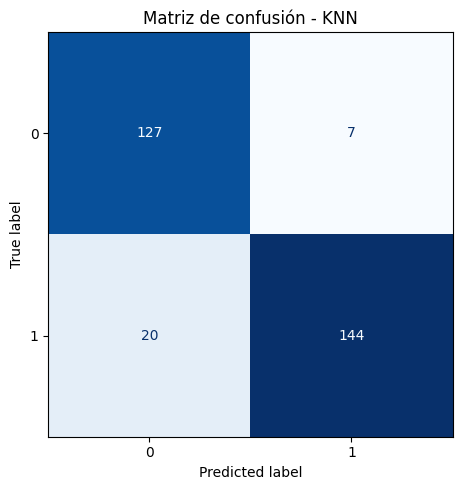

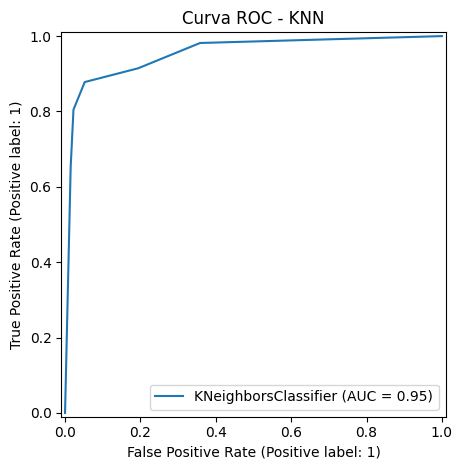


Comparación inicial de modelos:


,Modelo,Accuracy Train,Accuracy Test,Balanced Accuracy Train,Balanced Accuracy Test,Precision Train,Precision Test,Recall Train,Recall Test,F1 Train,F1 Test,ROC-AUC Train,ROC-AUC Test,Diferencia F1 Train-Test,Tiempo entrenamiento (seg)
1,Random Forest,1.0000,0.9396,1.000,0.9410,1.0000,0.9620,1.0000,0.9268,1.0000,0.9441,1.000,0.9813,0.0559,0.6842
0,Árbol de Decisión,1.0000,0.9295,1.000,0.9305,1.0000,0.9497,1.0000,0.9207,1.0000,0.9350,1.000,0.9305,0.0650,0.0324
2,KNN,0.9245,0.9094,0.926,0.9129,0.9494,0.9536,0.9119,0.8780,0.9302,0.9143,0.981,0.9541,0.0159,0.0035


In [ ]:
resultados_iniciales = []
modelos_entrenados_iniciales = {}

for nombre, modelo in modelos.items():
    resultado, modelo_entrenado = evaluar_modelo(
        nombre,
        modelo,
        X_train,
        y_train,
        X_test,
        y_test
    )

    resultados_iniciales.append(resultado)
    modelos_entrenados_iniciales[nombre] = modelo_entrenado

comparativa_inicial = pd.DataFrame(resultados_iniciales).sort_values(
    by="F1 Test",
    ascending=False
)

print("\nComparación inicial de modelos:")
display(comparativa_inicial.round(4))

Los tres modelos evaluados muestran un desempeño elevado en el conjunto de prueba. Sin embargo, Random Forest obtiene los mejores resultados en la mayoría de las métricas evaluadas, alcanzando el mayor F1-Score (0.944) y ROC-AUC (0.981).

El Árbol de Decisión presenta un rendimiento competitivo y mantiene la ventaja de ser fácilmente interpretable, aunque muestra una diferencia ligeramente mayor entre entrenamiento y prueba.

Por su parte, KNN obtiene resultados satisfactorios, pero inferiores a los modelos basados en árboles.

Con base en estos resultados, se seleccionan Random Forest y Árbol de Decisión para la etapa de ajuste fino de hiperparámetros.

##7. Análisis de subajuste y sobreajustes

In [ ]:
def interpretar_ajuste(row):
    diferencia = row["Diferencia F1 Train-Test"]

    if row["F1 Train"] < 0.70 and row["F1 Test"] < 0.70:
        return "Posible subajuste: bajo rendimiento tanto en entrenamiento como en prueba."
    elif diferencia > 0.10:
        return "Posible sobreajuste: el rendimiento en entrenamiento supera ampliamente al de prueba."
    else:
        return "Ajuste adecuado: métricas de entrenamiento y prueba son cercanas."

ajuste_inicial = comparativa_inicial[[
    "Modelo",
    "F1 Train",
    "F1 Test",
    "Diferencia F1 Train-Test",
    "Recall Test",
    "ROC-AUC Test",
    "Tiempo entrenamiento (seg)"
]].copy()

ajuste_inicial["Interpretación"] = ajuste_inicial.apply(interpretar_ajuste, axis=1)

print("\nAnálisis inicial de subajuste / sobreajuste:")
display(ajuste_inicial.round(4))


Análisis inicial de subajuste / sobreajuste:


,Modelo,F1 Train,F1 Test,Diferencia F1 Train-Test,Recall Test,ROC-AUC Test,Tiempo entrenamiento (seg),Interpretación
1,Random Forest,1.0000,0.9441,0.0559,0.9268,0.9813,0.6842,Ajuste adecuado: métricas de entrenamiento y p...
0,Árbol de Decisión,1.0000,0.9350,0.0650,0.9207,0.9305,0.0324,Ajuste adecuado: métricas de entrenamiento y p...
2,KNN,0.9302,0.9143,0.0159,0.8780,0.9541,0.0035,Ajuste adecuado: métricas de entrenamiento y p...


Los tres modelos presentan diferencias relativamente pequeñas entre el desempeño de entrenamiento y prueba, lo que indica una capacidad razonable de generalización.

Sin embargo, tanto Random Forest como Árbol de Decisión alcanzan un F1-Score perfecto en entrenamiento (1.00), lo que sugiere cierto nivel de sobreajuste al conjunto de entrenamiento. Aun así, la caída observada en el conjunto de prueba es moderada (menor al 7%), por lo que el sobreajuste no se considera crítico.

Por otro lado, KNN muestra la menor diferencia entre entrenamiento y prueba (1.59%), indicando un comportamiento más estable, aunque con un rendimiento general inferior.

En conjunto, Random Forest mantiene el mejor equilibrio entre desempeño predictivo y capacidad de generalización.

##8. Selección de los dos mejores modelos

In [ ]:
top2_modelos = comparativa_inicial.head(2)["Modelo"].tolist()

print("\nLos dos mejores modelos según F1-Score en prueba son:")
print(top2_modelos)

display(comparativa_inicial.head(2).round(4))


Los dos mejores modelos según F1-Score en prueba son:
['Random Forest', 'Árbol de Decisión']


,Modelo,Accuracy Train,Accuracy Test,Balanced Accuracy Train,Balanced Accuracy Test,Precision Train,Precision Test,Recall Train,Recall Test,F1 Train,F1 Test,ROC-AUC Train,ROC-AUC Test,Diferencia F1 Train-Test,Tiempo entrenamiento (seg)
1,Random Forest,1.0,0.9396,1.0,0.9410,1.0,0.9620,1.0,0.9268,1.0,0.9441,1.0,0.9813,0.0559,0.6842
0,Árbol de Decisión,1.0,0.9295,1.0,0.9305,1.0,0.9497,1.0,0.9207,1.0,0.9350,1.0,0.9305,0.0650,0.0324


La selección se realizó utilizando el F1-Score en el conjunto de prueba como métrica principal, debido a que el objetivo del proyecto es identificar correctamente a los estudiantes con riesgo de reprobar.

Los resultados muestran que:

Random Forest obtuvo el mejor F1-Score (0.944).
Árbol de Decisión obtuvo el segundo mejor F1-Score (0.935).
Ambos modelos también presentan los mayores valores de Recall y ROC-AUC.

Aunque KNN mostró un comportamiento estable y una menor diferencia entre entrenamiento y prueba, su desempeño global fue inferior al de los modelos basados en árboles.

Por esta razón, Random Forest y Árbol de Decisión fueron seleccionados para la etapa de optimización de hiperparámetros.

##9. Definición de hiperpárametros para ajuste fino

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

parametros = {
    "Árbol de Decisión": {
        "modelo": DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "params": {
            "max_depth": [3, 4, 5, 6, 8, 10],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [2, 5, 10, 20],
            "criterion": ["gini", "entropy"]
        }
    },

    "Random Forest": {
        "modelo": RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [4, 6, 8, 10],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [2, 5, 10]
        }
    },

    "KNN": {
        "modelo": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7, 9, 11, 15],
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan"]
        }
    }
}


Con base en los resultados obtenidos durante la comparación inicial, se seleccionaron los modelos con mejor desempeño para realizar una búsqueda sistemática de hiperparámetros.

Se utilizó validación cruzada estratificada de 5 particiones (Stratified K-Fold) para garantizar que cada partición mantuviera una distribución similar de estudiantes aprobados y reprobados.

La optimización se realizó utilizando F1-Score como métrica objetivo, debido a que representa un equilibrio entre Precision y Recall, aspectos fundamentales para identificar estudiantes con riesgo académico.

Los hiperparámetros evaluados fueron seleccionados por su influencia directa en la complejidad del modelo, su capacidad de generalización y el control del sobreajuste.

## 10. Ajuste fino de los dos mejores hiperparámetros

In [ ]:
resultados_grid = []
mejores_modelos_ajustados = {}

for nombre in top2_modelos:

    print("\n====================================================")
    print("Ajustando hiperparámetros para:", nombre)
    print("====================================================")

    inicio = time.time()

    grid = GridSearchCV(
        estimator=parametros[nombre]["modelo"],
        param_grid=parametros[nombre]["params"],
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    fin = time.time()
    tiempo_busqueda = fin - inicio

    mejores_modelos_ajustados[nombre] = grid.best_estimator_

    resultados_grid.append({
        "Modelo": nombre,
        "Mejor F1 CV": grid.best_score_,
        "Mejores hiperparámetros": grid.best_params_,
        "Tiempo búsqueda (seg)": tiempo_busqueda
    })

resultados_grid_df = pd.DataFrame(resultados_grid).sort_values(
    by="Mejor F1 CV",
    ascending=False
)

print("\nResultados del ajuste fino:")
display(resultados_grid_df)


Ajustando hiperparámetros para: Random Forest
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Ajustando hiperparámetros para: Árbol de Decisión
Fitting 5 folds for each of 144 candidates, totalling 720 fits

Resultados del ajuste fino:


,Modelo,Mejor F1 CV,Mejores hiperparámetros,Tiempo búsqueda (seg)
0,Random Forest,0.929415,"{'max_depth': 10, 'min_samples_leaf': 2, 'min_...",365.310612
1,Árbol de Decisión,0.924950,"{'criterion': 'entropy', 'max_depth': 6, 'min_...",9.946361


La búsqueda mediante GridSearchCV nos permitió identificar las configuraciones de hiperparámetros que maximizan el F1-Score promedio obtenido mediante validación cruzada.

Los resultados muestran que Random Forest continúa obteniendo el mejor desempeño global, alcanzando un F1-Score promedio de 0.9294 durante la validación cruzada.

Por su parte, el Árbol de Decisión obtuvo un desempeño muy cercano (0.9250), aunque ligeramente inferior.

Los hiperparámetros seleccionados reducen la complejidad de ambos modelos respecto a sus configuraciones iniciales, favoreciendo una mejor capacidad de generalización y disminuyendo el riesgo de sobreajuste.

## 11. Evaluación final de modelos ajustados


Random Forest Ajustado
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       134
           1       0.97      0.91      0.94       164

    accuracy                           0.94       298
   macro avg       0.93      0.94      0.94       298
weighted avg       0.94      0.94      0.94       298



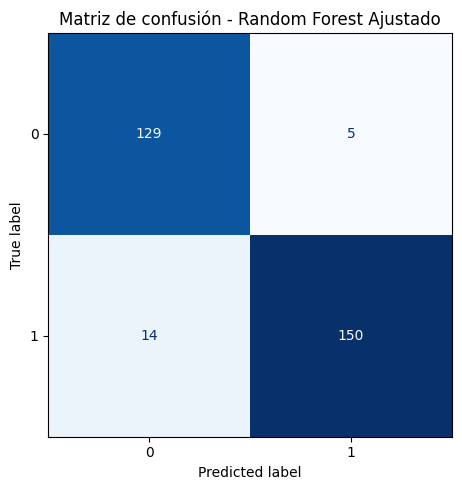

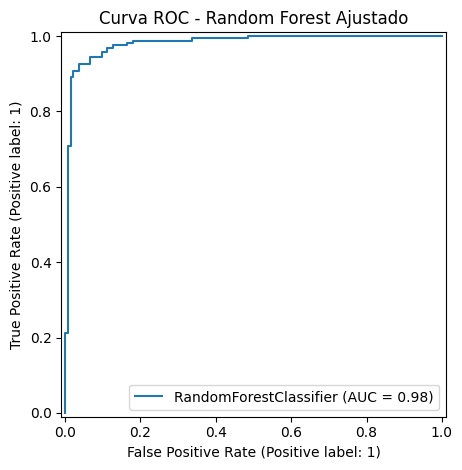


Árbol de Decisión Ajustado
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       134
           1       0.97      0.91      0.94       164

    accuracy                           0.94       298
   macro avg       0.93      0.94      0.94       298
weighted avg       0.94      0.94      0.94       298



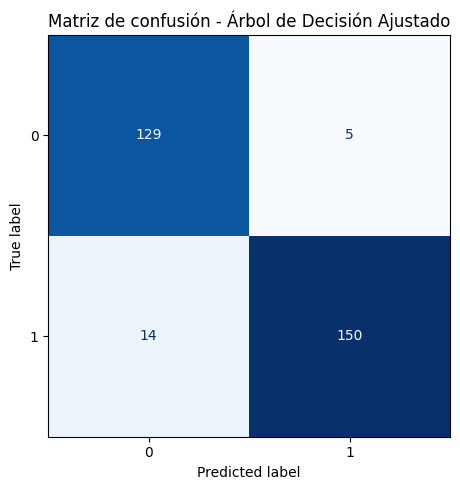

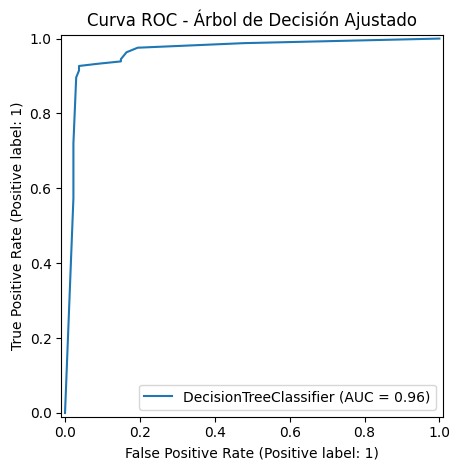


Comparación final de modelos ajustados:


,Modelo,Accuracy Train,Accuracy Test,Balanced Accuracy Train,Balanced Accuracy Test,Precision Train,Precision Test,Recall Train,Recall Test,F1 Train,F1 Test,ROC-AUC Train,ROC-AUC Test,Diferencia F1 Train-Test,Tiempo entrenamiento (seg)
0,Random Forest Ajustado,0.9656,0.9362,0.9660,0.9387,0.9753,0.9677,0.9620,0.9146,0.9686,0.9404,0.9974,0.9808,0.0282,0.7822
1,Árbol de Decisión Ajustado,0.9530,0.9362,0.9541,0.9387,0.9703,0.9677,0.9438,0.9146,0.9569,0.9404,0.9898,0.9644,0.0164,0.0240


In [ ]:
resultados_ajustados = []
modelos_finales_entrenados = {}

for nombre, modelo in mejores_modelos_ajustados.items():

    resultado, modelo_entrenado = evaluar_modelo(
        nombre + " Ajustado",
        modelo,
        X_train,
        y_train,
        X_test,
        y_test
    )

    resultados_ajustados.append(resultado)
    modelos_finales_entrenados[nombre + " Ajustado"] = modelo_entrenado

comparativa_ajustada = pd.DataFrame(resultados_ajustados).sort_values(
    by="F1 Test",
    ascending=False
)

print("\nComparación final de modelos ajustados:")
display(comparativa_ajustada.round(4))

El ajuste fino nos  permitió reducir la diferencia entre el desempeño en entrenamiento y prueba, especialmente en Random Forest, evidenciando una mejor capacidad de generalización.

Aunque el F1-Score en prueba no aumentó respecto a la versión inicial del Random Forest, el modelo ajustado mostró menor sobreajuste y mantuvo un desempeño altamente competitivo. Por otro lado, el Árbol de Decisión sí logró mejorar ligeramente su F1-Score después del ajuste.

Ambos modelos alcanzaron un F1-Score de 0.9404 en el conjunto de prueba. Sin embargo, Random Forest presentó un ROC-AUC superior (0.9808 frente a 0.9644), indicando una mejor capacidad para distinguir entre estudiantes aprobados y reprobados en distintos umbrales de decisión.

Por esta razón, Random Forest Ajustado se mantiene como el modelo más sólido para la etapa final del proyecto.

## 12. Comparación antes y después del ajuste

In [ ]:
comparacion_antes_despues = []

for nombre in top2_modelos:

    fila_inicial = comparativa_inicial[comparativa_inicial["Modelo"] == nombre].iloc[0]
    fila_ajustada = comparativa_ajustada[comparativa_ajustada["Modelo"] == nombre + " Ajustado"].iloc[0]

    comparacion_antes_despues.append({
        "Modelo": nombre,
        "F1 Antes": fila_inicial["F1 Test"],
        "F1 Después": fila_ajustada["F1 Test"],
        "Recall Antes": fila_inicial["Recall Test"],
        "Recall Después": fila_ajustada["Recall Test"],
        "ROC-AUC Antes": fila_inicial["ROC-AUC Test"],
        "ROC-AUC Después": fila_ajustada["ROC-AUC Test"],
        "Tiempo Antes": fila_inicial["Tiempo entrenamiento (seg)"],
        "Tiempo Después": fila_ajustada["Tiempo entrenamiento (seg)"]
    })

comparacion_antes_despues_df = pd.DataFrame(comparacion_antes_despues)

print("\nComparación antes y después del ajuste fino:")
display(comparacion_antes_despues_df.round(4))


Comparación antes y después del ajuste fino:


,Modelo,F1 Antes,F1 Después,Recall Antes,Recall Después,ROC-AUC Antes,ROC-AUC Después,Tiempo Antes,Tiempo Después
0,Random Forest,0.9441,0.9404,0.9268,0.9146,0.9813,0.9808,0.6842,0.7822
1,Árbol de Decisión,0.9350,0.9404,0.9207,0.9146,0.9305,0.9644,0.0324,0.0240


### Interpretación de la comparación antes y después del ajuste

El ajuste fino nos permitió encontrar configuraciones más robustas para los modelos seleccionados mediante validación cruzada estratificada.

En el caso de Random Forest, el F1-Score disminuyó ligeramente de 0.9441 a 0.9404; sin embargo, el modelo redujo la diferencia entre entrenamiento y prueba, indicando una menor tendencia al sobreajuste y una mejor capacidad de generalización.

Para el Árbol de Decisión, el ajuste fino produjo una mejora en F1-Score, pasando de 0.9350 a 0.9404, además de incrementar significativamente el valor de ROC-AUC.

En ambos casos se mantuvieron valores elevados de Recall, lo cual es importante debido a que el objetivo principal es detectar estudiantes con riesgo de reprobación.

## 13. Selección del modelo individual final

In [ ]:
mejor_modelo_final_nombre = comparativa_ajustada.iloc[0]["Modelo"]
mejor_modelo_final = modelos_finales_entrenados[mejor_modelo_final_nombre]

print("\n====================================================")
print("MODELO INDIVIDUAL FINAL SELECCIONADO")
print("====================================================")

print("Modelo final:", mejor_modelo_final_nombre)
print("F1 Test:", round(comparativa_ajustada.iloc[0]["F1 Test"], 4))
print("Recall Test:", round(comparativa_ajustada.iloc[0]["Recall Test"], 4))
print("Precision Test:", round(comparativa_ajustada.iloc[0]["Precision Test"], 4))
print("ROC-AUC Test:", round(comparativa_ajustada.iloc[0]["ROC-AUC Test"], 4))
print("Tiempo entrenamiento:", round(comparativa_ajustada.iloc[0]["Tiempo entrenamiento (seg)"], 4), "segundos")


MODELO INDIVIDUAL FINAL SELECCIONADO
Modelo final: Random Forest Ajustado
F1 Test: 0.9404
Recall Test: 0.9146
Precision Test: 0.9677
ROC-AUC Test: 0.9808
Tiempo entrenamiento: 0.7822 segundos


### Justificación del modelo final seleccionado

Aunque tanto Random Forest Ajustado como Árbol de Decisión Ajustado obtuvieron un F1-Score idéntico de 0.9404 en el conjunto de prueba, se seleccionó Random Forest Ajustado como modelo final.

Los principales argumentos son:

- Presenta el mayor ROC-AUC (0.9808), indicando una mejor capacidad discriminativa.
- Mantiene un Recall elevado (0.9146), permitiendo identificar adecuadamente estudiantes en riesgo.
- Reduce la diferencia entre entrenamiento y prueba respecto al modelo inicial, mostrando una mejor generalización.
- Al ser un método de ensamble, es menos sensible a variaciones de los datos que un árbol individual.

Aunque el Árbol de Decisión ofrece mayor interpretabilidad, el desempeño global de Random Forest resulta ligeramente superior para la tarea de predicción de riesgo académico.

## 14. Importancia de las características


Importancia de características - Random Forest Ajustado


,Característica,Importancia
6,Promedio_Evaluaciones,0.3410
4,Evaluación_3,0.1573
3,Evaluación_2,0.1243
5,Tareas_y_Pruebas_Cortas,0.0893
2,Evaluación_1,0.0874
9,Ratio_Tareas_vs_Evaluaciones,0.0498
8,Diferencia_Eval3_Eval1,0.0397
7,Desviacion_Evaluaciones,0.0380
1,Promedio de ingreso,0.0329
0,Año_lectivo,0.0140


<Figure size 900x600 with 0 Axes>

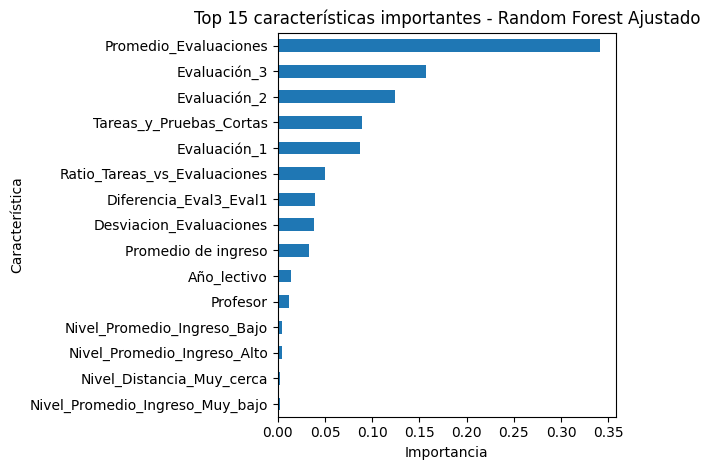

In [ ]:
def obtener_importancia(modelo, nombre_modelo, feature_names):

    if hasattr(modelo, "feature_importances_"):
        importancia = modelo.feature_importances_
    else:
        print("El modelo seleccionado no permite extraer importancia de características directamente.")
        return None

    importancia_df = pd.DataFrame({
        "Característica": feature_names,
        "Importancia": importancia
    }).sort_values(by="Importancia", ascending=False)

    print("\nImportancia de características -", nombre_modelo)
    display(importancia_df.head(15).round(4))

    plt.figure(figsize=(9, 6))
    importancia_df.head(15).sort_values("Importancia").plot(
        kind="barh",
        x="Característica",
        y="Importancia",
        legend=False
    )
    plt.title("Top 15 características importantes - " + nombre_modelo)
    plt.xlabel("Importancia")
    plt.ylabel("Característica")
    plt.tight_layout()
    plt.show()

    return importancia_df

importancia_modelo_final = obtener_importancia(
    mejor_modelo_final,
    mejor_modelo_final_nombre,
    X_train.columns
)

### Interpretación de las características más importantes

La variable con mayor contribución al modelo fue Promedio_Evaluaciones, representando aproximadamente el 34% de la importancia total.

Esto indica que el desempeño académico acumulado es el principal factor asociado al riesgo de reprobación.

Las siguientes variables más relevantes corresponden a las distintas evaluaciones parciales y actividades cortas, lo que sugiere que el comportamiento académico continuo tiene mayor poder predictivo que variables demográficas o contextuales.

Variables como nivel socioeconómico, distancia al campus o profesor muestran una contribución considerablemente menor, aunque fueron conservadas debido a que aportan información complementaria y no afectan negativamente el desempeño del modelo.

## 15. Conclusiones finales

Los resultados obtenidos demuestran que las variables derivadas del desempeño académico contienen información altamente relevante para identificar de manera temprana a estudiantes con riesgo de reprobación. La combinación de variables originales y características generadas mediante Feature Engineering permitió capturar patrones de comportamiento académico que fortalecieron significativamente la capacidad predictiva de los modelos evaluados.

A partir de la comparación entre Regresión Logística, Árbol de Decisión y Random Forest, se observó que los modelos basados en árboles fueron capaces de capturar relaciones no lineales entre las variables, obteniendo un desempeño superior al de los modelos lineales tradicionales. En particular, Random Forest Ajustado presentó el mejor resultado global, alcanzando un F1-Score de 0.9404 y un ROC-AUC de 0.9808, métricas que reflejan una excelente capacidad para diferenciar entre estudiantes aprobados y reprobados, manteniendo un adecuado equilibrio entre precisión y recall.

El proceso de optimización mediante búsqueda de hiperparámetros permitió mejorar el desempeño del modelo y reducir la brecha entre los resultados de entrenamiento y prueba, disminuyendo el riesgo de sobreajuste y fortaleciendo su capacidad de generalización sobre datos no observados. Asimismo, los resultados de validación cruzada mostraron un comportamiento consistente y estable, lo que aporta mayor confianza en la robustez del modelo seleccionado.

El análisis de importancia de variables confirmó que los factores más influyentes en la predicción corresponden principalmente al rendimiento académico del estudiante, destacando variables como Promedio_Evaluaciones, Evaluación_2, Evaluación_3 y Desviación_Evaluaciones. Esto sugiere que el desempeño en evaluaciones parciales constituye el principal indicador del riesgo de reprobación, mientras que variables contextuales como ingreso familiar o distancia presentan una contribución secundaria al proceso predictivo.

En términos prácticos, los resultados obtenidos evidencian que el modelo desarrollado puede servir como una herramienta de apoyo para la detección temprana de estudiantes en riesgo, permitiendo implementar estrategias de intervención académica antes de que ocurra la reprobación. Esto podría contribuir a mejorar los indicadores de desempeño estudiantil y optimizar la asignación de recursos de acompañamiento académico.

Finalmente, considerando su alto desempeño predictivo, estabilidad, interpretabilidad de las variables importantes y adecuada capacidad de generalización, Random Forest Ajustado se selecciona como el modelo de referencia para las siguientes etapas del proyecto, sobre el cual podrán evaluarse nuevas estrategias de optimización.